## Les compagnies aériennes ont‑elles des retards structurels ?

## ⚙️ ANOVA & Tukey

### ➡️ Importation des librairies nécessaires

In [2]:
import pandas as pd
import numpy as np

np.long = np.int_
np.ulong = np.int64

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=2.0.0 and <2.8.0 is required for this version of SciPy (detected version 1.26.4)
  from scipy.stats import gaussian_kde


### ➡️ Chargement et préparation du dataset

In [10]:
data = pd.read_csv("Data/flights_S6.csv")

# uniquement les colonnes utiles
data = data[["carrier", "arr_delay"]]

# suppression des valeurs manquantes
data = data.dropna(subset=["carrier", "arr_delay"])

data.head()

,carrier,arr_delay
0,UA,11.0
1,UA,20.0
2,AA,33.0
3,B6,-18.0
4,DL,-25.0


### ➡️ Retard moyen par compagnie

In [6]:
delay_by_carrier = data.groupby("carrier")["arr_delay"].mean().sort_values(ascending=False)
print(delay_by_carrier)

carrier
F9    21.920705
FL    20.115906
EV    15.796431
YV    15.556985
OO    11.931034
MQ    10.774733
WN     9.649120
B6     9.457973
9E     7.379669
UA     3.558011
US     2.129595
VX     1.764464
DL     1.644341
AA     0.364291
HA    -6.915205
AS    -9.930889
Name: arr_delay, dtype: float64


### ➡️ Visualisation des retards moyens

C:\Users\hp\AppData\Local\Temp\ipykernel_5268\808294807.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delay_by_carrier.index, y=delay_by_carrier.values, palette="viridis")


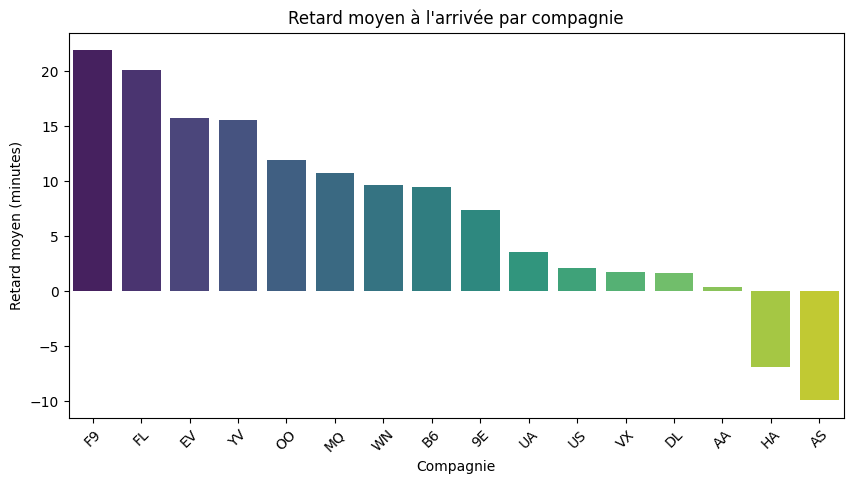

In [7]:
plt.figure(figsize=(10,5))
sns.barplot(x=delay_by_carrier.index, y=delay_by_carrier.values, palette="viridis")
plt.title("Retard moyen à l'arrivée par compagnie")
plt.ylabel("Retard moyen (minutes)")
plt.xlabel("Compagnie")
plt.xticks(rotation=45)
plt.show()

### ➡️ ANOVA

In [8]:
# Préparation des groupes
groups = [group["arr_delay"].values for name, group in data.groupby("carrier")]

anova_result = f_oneway(*groups)
print("Statistique F :", anova_result.statistic)
print("p-value :", anova_result.pvalue)

Statistique F : 332.87649104273197
p-value : 0.0


### ➡️ Test post-hoc Tukey HSD

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
    9E     AA  -7.0154    0.0  -8.4481  -5.5826   True
    9E     AS -17.3106    0.0 -23.1259 -11.4952   True
    9E     B6   2.0783    0.0   0.7524   3.4042   True
    9E     DL  -5.7353    0.0  -7.0826  -4.3881   True
    9E     EV   8.4168    0.0   7.0817   9.7519   True
    9E     F9   14.541    0.0    8.612  20.4701   True
    9E     FL  12.7362    0.0    9.806  15.6665   True
    9E     HA -14.2949    0.0 -22.5822  -6.0076   True
    9E     MQ   3.3951    0.0   1.8945   4.8957   True
    9E     OO   4.5514    1.0 -23.6545  32.7572  False
    9E     UA  -3.8217    0.0  -5.1371  -2.5062   True
    9E     US  -5.2501    0.0  -6.8291  -3.6711   True
    9E     VX  -5.6152    0.0  -8.0306  -3.1998   True
    9E     WN   2.2695 0.0017   0.4683   4.0706   True
    9E     YV   8.1773 0.0024   1.5689  14.7858   True
    AA    

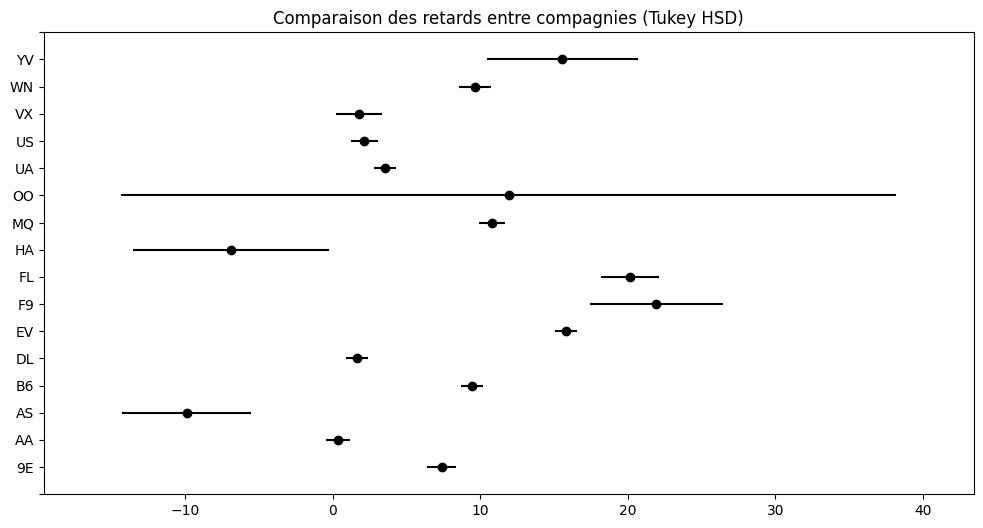

In [9]:
tukey = pairwise_tukeyhsd(endog=data["arr_delay"], groups=data["carrier"], alpha=0.05)
print(tukey)

# Visualisation
tukey.plot_simultaneous(figsize=(12,6))
plt.title("Comparaison des retards entre compagnies (Tukey HSD)")
plt.show()

### ➡️ Résumé

L’analyse des retards moyens par compagnie aérienne montre des écarts très marqués. Certaines compagnies présentent des retards moyens nettement plus élevés (F9, FL, EV, YV), tandis que d’autres affichent des retards très faibles, voire négatifs (HA, AS).

Le test ANOVA confirme que ces différences ne sont pas dues au hasard : Statistique F = 332.88 et p‑value = 0.0


Le test post‑hoc Tukey HSD permet d’identifier précisément quelles compagnies diffèrent entre elles. Les résultats montrent que :

Les compagnies F9, FL, EV, YV ont des retards significativement plus élevés que la majorité des autres transporteurs.

Les compagnies HA et AS se distinguent par des retards très faibles, souvent significativement inférieurs à ceux des autres compagnies.

De nombreuses comparaisons sont significatives (reject = True), ce qui confirme que les écarts observés sont structurels et non aléatoires.

Quelques comparaisons ne sont pas significatives (ex : 9E vs OO, WN vs YV), ceci révèle juste que certaines compagnies ont des performances similaires.

En conclusion, les retards ne sont pas uniformes dans le secteur, ils sont structurellement différents selon les compagnies, une reflexion des réalités opérationnelles propres à chaque transporteur (gestion des rotations, hubs, flotte, organisation interne, etc.).